# biexciton model with cavity coupling (mediated by dark states)
### Accessible states
Cavity has M fock states with |0> being its ground state and |n> being its nth excited state with n photons in the cavity
####
Material has a custom Hilbert space with accessible states:

|g>: ground

|H>: 1 heavy exciton (bright)

|L>: 1 light exciton (dark)

|HH>: 2 heavy excitons (forming a biexciton if neighbors in the lattice)

|HL>: 1 heavy and 1 light exciton (forming a biexciton if neighbors in the lattice)

|LL>: 2 light excitons (forming a biexciton if neighbors in the lattice)

In [1]:
import matplotlib.pyplot as plt

# -*- coding: utf-8 -*-
"""
Created on Thu June 10 10:xx:xx 2026

@author: felix
"""

import sys
import time

from qutip import *
import numpy as np
from qudpy.Classes import *
import qudpy.plot_functions as pf
import ufss
import matplotlib.animation as animation
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import axes3d
import pickle

np.set_printoptions(threshold=sys.maxsize, linewidth=190, precision=3, suppress=True)

plt.style.use('dark_background')

hbar = 0.658211951  # in eV fs
kB = 8.617333262 * 1e-5  # Boltzmann constant eV/K
T = 300  # temperature in K
kT = T * kB
beta = 1 / kT

In [2]:
scale = 45

en_exc=1.4907 # excitonic resonant energy in eV
detuning = -0.00 # detuning between exciton and cavity in eV
en_cav=en_exc + detuning # cavity resonant energy in eV

N=2 # number of lattice sites
M=3 # number of fock basis for cavity mode. # maybe -> Use larger value for stronger couplings

rabi=0.00303 * scale # vaccum rabi splitting
g=rabi/2 # coupling strength for light-matter interaction in eV
J=0.00075 * scale # coupling strength between heavy and light excitons (from small band gap energy difference)
n_th=0.1 # average number thermal photons in the bath coupling to the resonator

muc=1.0 # dipole strength for the cavity
muz=1.0 # dipole strength for the particle

kappa=0.05 # cavity decay strength
gamma_phase=0.01 # atomic dephasing strength
gamma_decay=0.01 # atomic decay strength
gamma_hl=0.1 # exciton species swapping strength

hh_bind=0.2 # strength of neighboring HH binding
ll_bind=0.2 # strength of neighboring LL binding
hl_bind=0.2 # strength of neighboring HL/LH binding
hg_swap=0.1 # strength of transition for heavy excitons to neighbor empty lattice site. In Lindbladian operators.
lg_swap=0.1 # strength of transition for light excitons to neighbor empty lattice site. In Lindbladian operators.

h_str = 1 # strength of interaction coupling between photon-heavy exciton
l_str = 0.01 # strength of interaction coupling between photon-light exciton

dark="k" # x in ["light", "heavy"] if x has no allowed transition from perturbation. anything other than those to use h_str and l_str
model="no_rw" # "no_rw" for no rotating wave approximation, "rw" for rotating wave approximation

decay="no_atomic" # "no_atomic" "atomic" # does nothing now
time2=120 # population time delay
directory="results/exc-exc/" # result directory
anim="no" # animate # would make a gif if it didnt take 10mins per spectra

# 1 exciton maximum
#### essentially N=inf because of translation symmetry

In [3]:
if N == 1:

    # setting up dm
    fock_ = fock_dm(M, 0)
    exc_basis0 = np.zeros((3, 3));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,1h,1l
    exciton_space = exc_basis * exc_basis.dag()  # ground state of Hamiltonian
    rho = tensor(fock_, exciton_space)

    wc = en_cav / hbar
    wz_h, wz_l = en_exc / hbar  # atom resonant frequencies

    a = tensor([destroy(M)] + [qeye(3)])

    H_cav = hbar * (wc * a.dag() * a)  # cavity energy

### still 1 exciton
Lowering operators for each transition + global for perturbation

In [4]:
if N == 1:

    # each individual lowering operators
    h_low = np.zeros_like(exc_basis0);
    h_low[0, 1] = 1;
    h_low = tensor(qeye(M), Qobj(h_low))
    l_low = np.zeros_like(exc_basis0);
    l_low[0, 2] = 1;
    l_low = tensor(qeye(M), Qobj(l_low))

    exc_h_low = h_low
    exc_l_low = l_low
    if dark == "light":
        exc_low = exc_h_low
    elif dark == "heavy":
        exc_low = exc_l_low
    else:
        exc_low = exc_h_low + exc_l_low

### still 1 exciton
*H_exc* is the exciton energy hamiltonian with binding energy difference

*H_coupling* is the coupling hamiltonian between heavy-light excitons

In [5]:
if N == 1:

    H_exc = hbar * wz_h * h_low.dag() * h_low + hbar * wz_l * l_low.dag() * l_low

    H_coupling = h_low.dag() * l_low  # H-L coupling
    H_coupling += H_coupling.dag()
    # print("H_coupling", H_coupling)

# 2 lattice sites
2 exciton states will always be bound bi-excitons

In [6]:
if N == 2:

    # setting up dm
    fock_ = fock_dm(M, 0)
    exc_basis0 = np.zeros((6, 6));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,1h,1l,2h-bound,hl-bound,2lbound
    exciton_space = exc_basis * exc_basis.dag()  # ground state of Hamiltonian
    rho = tensor(fock_, exciton_space)

    wc = en_cav / hbar
    wz_h = wz_l = en_exc / hbar  # atom resonant frequencies

    a = tensor([destroy(M)] + [qeye(6)])

    H_cav = hbar * (wc * a.dag() * a)  # cavity energy

### still 2 lattice sites
Lowering operators for each transition + global for perturbation

In [7]:
if N == 2:

    # each individual lowering operators
    h_low = np.zeros_like(exc_basis0);
    h_low[0, 1] = 1;
    h_low = tensor(qeye(M), Qobj(h_low))
    hh_bound_low = np.zeros_like(exc_basis0);
    hh_bound_low[1, 3] = 1;
    hh_bound_low = tensor(qeye(M), Qobj(hh_bound_low))
    l_low = np.zeros_like(exc_basis0);
    l_low[0, 2] = 1;
    l_low = tensor(qeye(M), Qobj(l_low))
    ll_bound_low = np.zeros_like(exc_basis0);
    ll_bound_low[2, 5] = 1;
    ll_bound_low = tensor(qeye(M), Qobj(ll_bound_low))
    hl_h_bound_low = np.zeros_like(exc_basis0);
    hl_h_bound_low[1, 4] = 1 / np.sqrt(2);
    hl_h_bound_low = tensor(qeye(M), Qobj(hl_h_bound_low))  # lowers to h
    hl_l_bound_low = np.zeros_like(exc_basis0);
    hl_l_bound_low[2, 4] = 1 / np.sqrt(2);
    hl_l_bound_low = tensor(qeye(M), Qobj(hl_l_bound_low))  # lowers to l

    exc_h_low = h_low + hh_bound_low + hl_l_bound_low
    exc_l_low = l_low + hl_h_bound_low + ll_bound_low
    if dark == "light": exc_low = exc_h_low
    elif dark == "heavy": exc_low = exc_l_low
    else: exc_low = exc_h_low + exc_l_low

### still 2 lattice sites
*H_exc* is the exciton energy hamiltonian with binding energy difference

*H_coupling* is the coupling hamiltonian between heavy-light excitons

In [8]:
if N == 2:

    H_exc = (hbar * wz_h * h_low.dag() * h_low +  # h-pop
             hbar * wz_l * l_low.dag() * l_low +  # l-pop
             hbar * (2 * wz_h - hh_bind / 2) * hh_bound_low.dag() * hh_bound_low +  # hh-biexc-pop
             hbar * (2 * wz_l - ll_bind / 2) * ll_bound_low.dag() * ll_bound_low +  # ll-biexc-pop
             hbar * (wz_h + wz_l - hl_bind / 2) * (hl_h_bound_low.dag() * hl_h_bound_low + hl_l_bound_low.dag() * hl_l_bound_low))  # hl-biexc-pop

    H_coupling = h_low.dag() * l_low  # H-L coupling. 1 exciton states
    H_coupling += hh_bound_low.dag() * hl_h_bound_low + hl_l_bound_low.dag() * ll_bound_low #HH-HL, HL-LL coupling. 2 exciton states
    H_coupling += H_coupling.dag()
    # print("H_coupling", H_coupling)

# 3 lattice sites


In [9]:
if N == 3:

    # setting up dm
    fock_ = fock_dm(M, 0)
    exc_basis0 = np.zeros((12, 12));
    exc_basis0[0, 0] = 1;
    exc_basis = Qobj(exc_basis0)  # ground,1h-mid,1h-edge,1l-mid,1l-edge,2h-bound,2h,hl-bound,h0l,l0h,2lbound,2l
    exciton_space = exc_basis * exc_basis.dag()  # ground state of Hamiltonian
    rho = tensor(fock_, exciton_space)

    wc = en_cav / hbar
    wz_h, wz_l = en_exc / hbar  # atom resonant frequencies

    a = tensor([destroy(M)] + [qeye(12)])

    H_cav = hbar * (wc * a.dag() * a)  # cavity energy

In [10]:
if N == 3:

    # each individual lowering operators
    h_m_low = np.zeros_like(exc_basis0); h_m_low[0, 1] = 1; h_m_low = tensor(qeye(M), Qobj(h_m_low)) # lowers 0h0 to g
    h_e_low = np.zeros_like(exc_basis0); h_e_low[0, 2] = 1; h_e_low = tensor(qeye(M), Qobj(h_e_low)) # lowers 00h to g
    l_m_low = np.zeros_like(exc_basis0); l_m_low[0, 3] = 1; l_m_low = tensor(qeye(M), Qobj(l_m_low)) # lowers 0l0 to g
    l_e_low = np.zeros_like(exc_basis0); l_e_low[0, 4] = 1; l_e_low = tensor(qeye(M), Qobj(l_e_low)) # lowers 00l to g

    hh_m_low = np.zeros_like(exc_basis0); hh_m_low[[1,2],[5,5]] = 1 / np.sqrt(2);
    hh_m_low = tensor(qeye(M), Qobj(hh_m_low)) # lowers 0hh to 0h0 + 00h
    hh_e_low = np.zeros_like(exc_basis0); hh_e_low[2, 6] = 1;
    hh_e_low = tensor(qeye(M), Qobj(hh_e_low)) # lowers h0h to 00h
    ll_m_low = np.zeros_like(exc_basis0); ll_m_low[[3,4], [10,10]] = 1 / np.sqrt(2);
    ll_m_low = tensor(qeye(M), Qobj(ll_m_low)) # lowers 0ll to 0l0 + 00l
    ll_e_low = np.zeros_like(exc_basis0); ll_e_low[4, 11] = 1;
    ll_e_low = tensor(qeye(M), Qobj(ll_e_low)) # lowers l0l to 00l

    hl_m_h_low = np.zeros_like(exc_basis0); hl_m_h_low[4,7] = 1 / np.sqrt(2);
    hl_m_h_low = tensor(qeye(M), Qobj(hl_m_h_low))  # lowers 0hl to 00l
    hl_m_l_low = np.zeros_like(exc_basis0); hl_m_l_low[1,7] = 1 / np.sqrt(2);
    hl_m_l_low = tensor(qeye(M), Qobj(hl_m_l_low))  # lowers 0hl to 0h0
    lh_m_h_low = np.zeros_like(exc_basis0); lh_m_h_low[3,8] = 1 / np.sqrt(2);
    lh_m_h_low = tensor(qeye(M), Qobj(lh_m_h_low))  # lowers 0lh to 0l0
    lh_m_l_low = np.zeros_like(exc_basis0); lh_m_l_low[2,8] = 1 / np.sqrt(2);
    lh_m_l_low = tensor(qeye(M), Qobj(lh_m_l_low))  # lowers 0lh to 00h
    hl_e_h_low = np.zeros_like(exc_basis0); hl_e_h_low[4,9] = 1 / np.sqrt(2);
    hl_e_h_low = tensor(qeye(M), Qobj(hl_e_h_low))  # lowers h0l to 00l
    hl_e_l_low = np.zeros_like(exc_basis0); hl_e_l_low[2,9] = 1 / np.sqrt(2);
    hl_e_l_low = tensor(qeye(M), Qobj(hl_e_l_low))  # lowers h0l to h00

    # group lowering operators
    exc_h_low = h_m_low + h_e_low + hh_m_low + hh_e_low + hl_m_l_low + hl_e_l_low + lh_m_h_low
    exc_l_low = l_m_low + l_e_low + ll_m_low + ll_e_low + hl_m_h_low + hl_e_h_low + lh_m_l_low
    if dark == "light": exc_low = exc_h_low
    elif dark == "heavy": exc_low = exc_l_low
    else: exc_low = exc_h_low + exc_l_low

In [11]:
if N == 3:

    H_exc = (hbar * wz_h * (h_m_low.dag() * h_m_low + h_e_low.dag() * h_e_low) +  # h pop
             hbar * wz_l * (l_m_low.dag() * l_m_low + l_e_low.dag() * l_e_low) +  # l pop
             hbar * (2 * wz_h - hh_bind / 2) * hh_m_low.dag() * hh_m_low +  # hh-m pop
             hbar * 2 * wz_h * hh_e_low.dag() * hh_e_low +  # hh-e pop
             hbar * (2 * wz_l - ll_bind / 2) * ll_m_low.dag() * ll_m_low +  # ll-m pop
             hbar * 2 * wz_l * ll_e_low.dag() * ll_e_low +  # ll-e pop
             hbar * (wz_h + wz_l) * (hl_m_h_low.dag() * hl_m_h_low + hl_m_l_low.dag() * hl_m_l_low) +  # hl-m pop
             hbar * (wz_h + wz_l) * (lh_m_h_low.dag() * lh_m_h_low + lh_m_l_low.dag() * lh_m_l_low) +  # lh-m pop
             hbar * (wz_h + wz_l - hl_bind / 2) * (hl_e_h_low.dag() * hl_e_h_low + hl_e_l_low.dag() * hl_e_l_low))  # hl-e pop

    H_coupling = h_m_low.dag() * l_m_low + h_e_low.dag() * l_e_low  # H-L coupling. 1 exciton states
    H_coupling += hh_m_low.dag() * (hl_m_l_low + lh_m_l_low) + hh_e_low.dag() * hl_e_l_low #HH-HL coupling. 2 exciton states
    H_coupling += hl_m_h_low.dag() * ll_m_low + lh_m_h_low.dag() * ll_m_low + hl_e_h_low.dag() * ll_e_low #HL-LL coupling. 2 exciton states
    H_coupling += H_coupling.dag()
    # print("H_coupling", H_coupling)

# Hamiltonian, dipole op., lowering op., collapse ops.
*H_cav* is the cavity energy.

*H_exc* is the exciton energy with binding energy difference for bi-excitons.
#####
*H_int* is the photon(cavity)-exciton(matter) interaction coupling with factor *g* strength.

*H_coupling* is the heavy exciton-light exciton coupling with factor *J* strength. Only states with the same number of excitons and a single different exciton species will couple.
###
*mud* is the dipole operator with the cavity lowering + raising and exciton lowering + raising operators.

*ad* is the total lowering operator for the perturbation to impact the system.
###
*c_cav_rel* and *c_cav_exc* are the Lindblad cavity relaxation/excitation operators.

*c_col_dep* is the Lindblad collective dephasing operator which acts on the exciton populations.

*c_mat_rel* and *c_mat_exc* are the Lindblad cavity matter relaxation/excitation operators.

*c_h_l* and *c_l_h* are the Lindblad heavy→light and light→heavy exciton transition operators.

*c_swap* is the Lindblad exciton→neighboring empty lattice site transition operator.

In [12]:
if model == "no_rw":
    if dark == "light":
        H_int = hbar * (a + a.dag()) * (exc_h_low + exc_h_low.dag())
    elif dark == "heavy":
        H_int = hbar * (a + a.dag()) * (exc_l_low + exc_l_low.dag())
    else:
        H_int = hbar * (a + a.dag()) * (h_str * (exc_h_low + exc_h_low.dag()) + l_str * (exc_l_low + exc_l_low.dag()))
elif model == "rw":
    if dark == "light":
        H_int = hbar * (a.dag() * exc_h_low + a * exc_h_low.dag())
    elif dark == "heavy":
        H_int = hbar * (a.dag() * exc_l_low + a * exc_l_low.dag())
    else:
        H_int = hbar * (a.dag() * (h_str * exc_h_low + l_str * exc_l_low) +
                        a * (h_str * exc_h_low.dag() + l_str * exc_l_low.dag()))

H0 = H_cav + H_exc  # diagonal hamiltonian
H = H0 + g * H_int + J * H_coupling  # total hamiltonian
# print("H0", H0)
# print("H_int", H_int)
print("H", H)

mud = muc * (a + a.dag()) + muz * (exc_low + exc_low.dag()) # dipole operator
ad = muc * a + muz * exc_low # lowering operator
# print("mud", mud)
# print("ad", ad)

# collapse operators
c_cav_rel = np.sqrt(kappa * (n_th + 1)) * a # cavity relaxation
c_cav_exc = np.sqrt(kappa * n_th) * a.dag() # cavity excitation
c_col_dep = np.sqrt(gamma_phase) * H_exc # collective dephasing
c_mat_rel = np.sqrt(gamma_decay * (n_th + 1)) * exc_low # collective exciton relaxation
c_mat_exc = np.sqrt(gamma_decay * n_th) * exc_low.dag() # collective exciton excitation
c_h_l = np.sqrt(gamma_hl * (n_th + 1)) * exc_l_low.dag() * exc_h_low # heavy exciton to light exciton transition
c_l_h = np.sqrt(gamma_hl * n_th) * exc_h_low.dag() * exc_l_low # light exciton to heavy exciton transition
c_ops = [c_cav_rel, c_cav_exc, c_col_dep, c_mat_rel, c_mat_exc, c_h_l, c_l_h]

if N == 3:
    c_swap = h_m_low.dag() * h_e_low + h_e_low.dag() * h_m_low + l_m_low.dag() * l_e_low + l_e_low.dag() * l_m_low
    c_swap += hh_m_low.dag() * hh_e_low + hh_e_low.dag() * hh_m_low + ll_m_low.dag() * ll_e_low + ll_e_low.dag() * ll_m_low
    c_swap += hl_e_h_low.dag() * hl_m_h_low + hl_e_l_low.dag() * lh_m_l_low
    c_swap += lh_m_l_low.dag() * hl_e_l_low + hl_m_h_low.dag() * hl_e_h_low

    c_ops.append(c_swap)

H Quantum object: dims=[[3, 6], [3, 6]], shape=(18, 18), type='oper', dtype=Dia, isherm=True
Qobj data =
[[0.    0.    0.    0.    0.    0.    0.    0.045 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    1.491 0.034 0.    0.    0.    0.045 0.    0.    0.045 0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.034 1.491 0.    0.    0.    0.    0.    0.    0.    0.032 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    2.916 0.024 0.    0.    0.045 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.024 2.916 0.024 0.    0.    0.032 0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.024 2.916 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.045 0.    0.    0.    0.    1.486 0.    0.    0.    0.    0.    0.    0.063 0.001 0.    0.    0.   ]
 [0.045 0.    0.    0.045 0.    0.    0.    2.977 0.034 0.    0.    0.    0.063 0.    0.    0.063 0.    0.   ]
 [0.   

### Initializing the system

In [13]:
print("dimensionality of Hilbert-space: ", H.shape)

# setting up system
syst = System(H=H, rho=rho, a=ad, u=mud, c_ops=c_ops, diagonalize=True)

en, T = H.eigenstates()
print("eigenenergies", en)
# print("eigenstates", T)

print("system has been intialized")

# # calculate the expectation value of the number of photons in the cavity
# n_vec = expect(a.dag() * a, rho)
# # print("expectation of number of photons: ", n_vec)
# n2_vec = expect(a.dag() * a*a.dag() * a, rho)
# a_vec = expect(a, rho)

# graph_title = f"{time.localtime().tm_hour:02d}:{time.localtime().tm_min:02d}_N{N}_M{M}_g{g}_J{J}_k{kappa}_gph{gamma_phase}_gdc{gamma_decay}_ghl{gamma_hl}"
graph_title = f"N{N}_M{M}_g{g}_J{J}_detun{detuning:.4f}_k{kappa}_gph{gamma_phase}_gdc{gamma_decay}_ghl{gamma_hl}"
# print(graph_title)

dimensionality of Hilbert-space:  (18, 18)
diagonalizing Hamiltonian and transforming everything into eigen-basis except rho
system initialized
eigenenergies [-0.001  1.432  1.488  1.545  2.861  2.896  2.93   2.94   2.987  3.056  4.34   4.383  4.416  4.464  4.528  5.854  5.888  5.922]
system has been intialized


### Linear spectra + pickle saving

Starting dipole master equation calculation
10.0%. Run time:   4.91s. Est. time left: 00:00:00:44
20.0%. Run time:   9.69s. Est. time left: 00:00:00:38
30.0%. Run time:  15.61s. Est. time left: 00:00:00:36
40.0%. Run time:  20.50s. Est. time left: 00:00:00:30
50.1%. Run time:  24.18s. Est. time left: 00:00:00:24
60.1%. Run time:  29.89s. Est. time left: 00:00:00:19
70.1%. Run time:  34.44s. Est. time left: 00:00:00:14
80.1%. Run time:  40.79s. Est. time left: 00:00:00:10
90.1%. Run time:  44.50s. Est. time left: 00:00:00:04
100.0%. Run time:  50.32s. Est. time left: 00:00:00:00
Total run time:  50.32s


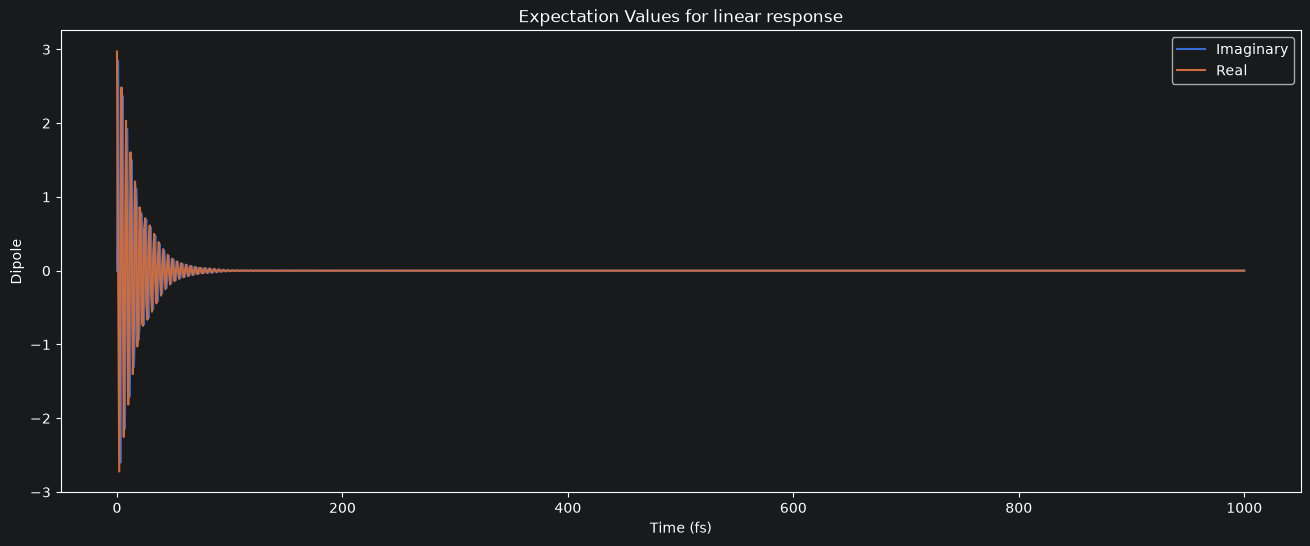

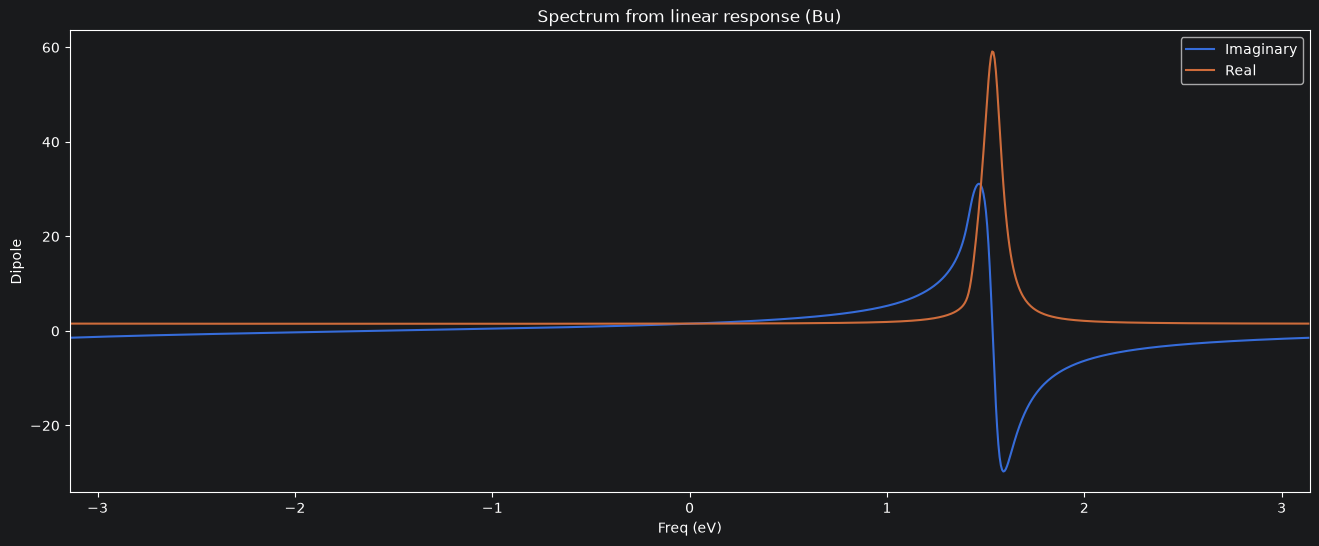

In [14]:
d0 = 1000

dipole, t_list, spec, freq = syst.linear_spec(d0, r=1, dir=directory, title_graph="lindip_"+graph_title)

os.makedirs("results/exc-exc_data/"+graph_title, exist_ok=True)
with open("results/exc-exc_data/"+graph_title+"/dip.pkl", "wb") as file:
    pickle.dump(dipole, file)
with open("results/exc-exc_data/"+graph_title+"/tlist.pkl", "wb") as file:
    pickle.dump(t_list, file)
with open("results/exc-exc_data/"+graph_title+"/spec.pkl", "wb") as file:
    pickle.dump(spec, file)
with open("results/exc-exc_data/"+graph_title+"/freq.pkl", "wb") as file:
    pickle.dump(freq, file)

#### pickle loading

In [15]:
# with open("results/exc-exc_data/"+graph_title+"/dip.pkl", "rb") as file:
#     dipole = pickle.load(file)
# with open("results/exc-exc_data/"+graph_title+"/tlist.pkl", "rb") as file:
#     t_list = pickle.load(file)
# with open("results/exc-exc_data/"+graph_title+"/spec.pkl", "rb") as file:
#     spec = pickle.load(file)
# with open("results/exc-exc_data/"+graph_title+"/freq.pkl", "rb") as file:
#     freq = pickle.load(file)

### Linear plotting

<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:11: SyntaxWarning: invalid escape sequence '\ '
C:\Users\felix\AppData\Local\Temp\ipykernel_16832\743214745.py:2: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(t_list, np.real(dipole), label="$J_{0} = 0 \ eV$")  # real part of the dipole
C:\Users\felix\AppData\Local\Temp\ipykernel_16832\743214745.py:11: SyntaxWarning: invalid escape sequence '\ '
  plt.plot(freq, np.real(spec), label="$J_{0} = 0 \ eV$")  # real part of the spectrum


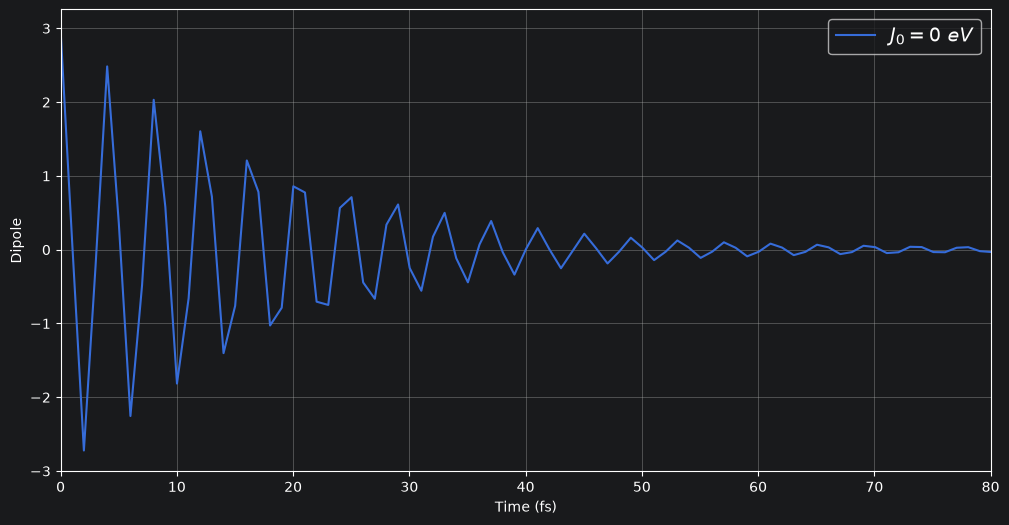

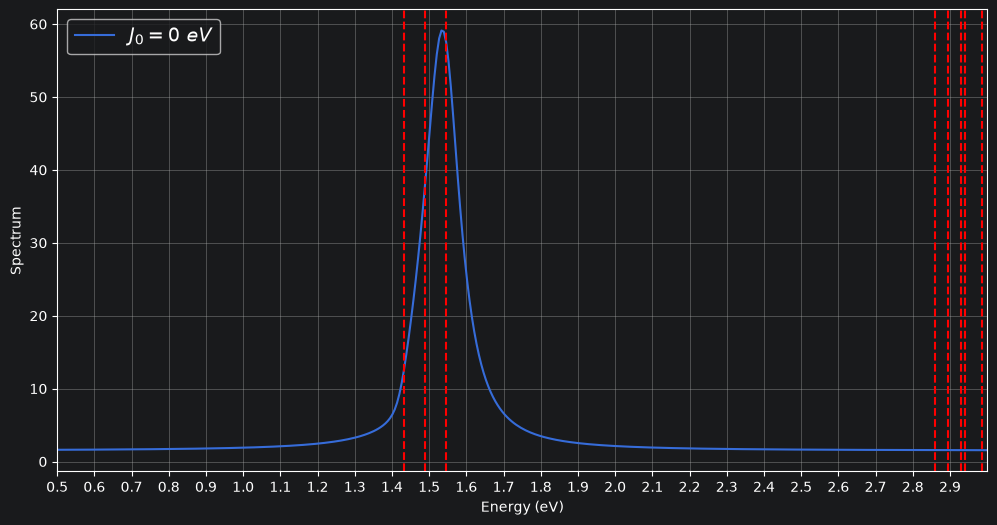

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(t_list, np.real(dipole), label="$J_{0} = 0 \ eV$")  # real part of the dipole
plt.xlim(0, 80)
plt.xlabel("Time (fs)")
plt.ylabel("Dipole")
plt.legend(fontsize=14)
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(freq, np.real(spec), label="$J_{0} = 0 \ eV$")  # real part of the spectrum
plt.xlim(0.5, 3.0)
plt.xticks(np.arange(0.5, 3.0, 0.1))
for i in H.eigenenergies():
    plt.axvline(x=i, color='red', linestyle='--')
plt.xlabel("Energy (eV)")
plt.ylabel("Spectrum")
plt.legend(fontsize=14)
plt.grid()
plt.savefig(directory+"linspec_"+graph_title+".png")
plt.show()

### 3rd order spectra + pickle saving
For time delays, it seems you need at least as many as 1/(weakest coupling) to see the specific features. Weaker couplings means bigger time delays aka longer simulation run time.

In [17]:
# Setting up the required double sided diagrams for tests
# DiagramGenerator class, or DG for short
DG = ufss.DiagramGenerator
# initialize the module

R3rd = DG()  # DG takes a single key-word argument, which has the default value detection_type = 'polarization'
# DiagramAutomation needs to know the phase-matching/-cycling condition
R3rd.set_phase_discrimination([(0, 1), (1, 0), (1, 0)])  # setting phase-matching condition for rephasing diagrams R1,2,3
# Set the pulse interval
t_pulse = np.array([-1, 1])
R3rd.efield_times = [t_pulse] * 4

# Creating diagrams for pulse arrival times 0, 120, 240 and detection time 360.
[R3, R1, R2] = R3rd.get_diagrams([0, 120, 240, 360])
rephasing = [R1, R2, R3]
print('the rephasing diagrams are R1, R2 and R3 ', rephasing)

# setting conditions for and generating non-rephasing diagrams R4, R5 and R6
R3rd.set_phase_discrimination([(1, 0), (0, 1), (1, 0)])
[R6, R4, R5] = R3rd.get_diagrams([0, 120, 240, 240])
nonrephasing = [R4, R5, R6]
print('the non-rephasing diagrams are R4, R5 and R6', nonrephasing)

# syst.diagram_donkey([0, 120, 120+time2, 240+time2], [R3], r=10, title_graph=None, plot_graph=False, dir=directory)

print("finished setup stage")

# generating 2Dcoherence response for rephasing diagrams
time_delays = [200, 20, 200]
scan_id = [0, 2]
response_list = []
diagrams = rephasing + nonrephasing
for k in range(6):
    states, t1, t2, dipole = syst.coherence2d(time_delays, diagrams[k], scan_id, r=1, parallel=True)
    print('diagram ', k, ' done')
    response_list.append(1j * dipole)
spectra_list, extent, f1, f2 = syst.spectra(np.imag(response_list), resolution=1)

with open("results/exc-exc_data/"+graph_title+"/spec2d.pkl", "wb") as file:
    pickle.dump(spectra_list, file)
with open("results/exc-exc_data/"+graph_title+"/extent.pkl", "wb") as file:
    pickle.dump(extent, file)
with open("results/exc-exc_data/"+graph_title+"/f1.pkl", "wb") as file:
    pickle.dump(f1, file)
with open("results/exc-exc_data/"+graph_title+"/f2.pkl", "wb") as file:
    pickle.dump(f2, file)

the rephasing diagrams are R1, R2 and R3  [(('Bu', 0), ('Ku', 1), ('Bd', 2)), (('Bu', 0), ('Bd', 1), ('Ku', 2)), (('Bu', 0), ('Ku', 1), ('Ku', 2))]
the non-rephasing diagrams are R4, R5 and R6 [(('Ku', 0), ('Bu', 1), ('Ku', 2)), (('Ku', 0), ('Bu', 1), ('Bd', 2)), (('Ku', 0), ('Kd', 1), ('Ku', 2))]
finished setup stage
First scan done, starting second scan. Remaining time = First Scan Time x number of steps in second scan/number of processors


ValueError: Function to integrate must not return a tuple.

#### pickle loading

In [ ]:
# with open("results/exc-exc_data/"+graph_title+"/spec2d.pkl", "rb") as file:
#     spec2d = pickle.load(file)
# with open("results/exc-exc_data/"+graph_title+"/extent.pkl", "rb") as file:
#     extent = pickle.load(file)
# with open("results/exc-exc_data/"+graph_title+"/f1.pkl", "rb") as file:
#     f1 = pickle.load(file)
# with open("results/exc-exc_data/"+graph_title+"/f2.pkl", "rb") as file:
#     f2 = pickle.load(file)

### 3rd order plotting

In [ ]:
rephasing_spectra = spectra_list[:3]
rephasing_spectra.append(np.sum(spectra_list[:3], 0))
pf.silva_plot_contourf(rephasing_spectra, f1, f2, labels=['E emission', 'E absorption'],
          scale='linear', color_map='PuOr', title_list = ['$R_1$', '$R_2$', '$R_3$', '$R_{rephasing}$'],
          center_scale=False, plot_sum=False, plot_quadrant='2', zoom_coor=[-2.8,-2,2,2.8],
          invert_y=False, diagonals=[True, False], nlevels=15,
          title_graph=graph_title, plot_graph=True, direc=directory)